In [1]:
import yfinance as yf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [17]:
sp500_tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B",
    "JPM", "JNJ", "V", "UNH", "XOM", "PG", "MA", "HD", "CVX", "MRK",
    "ABBV", "PEP", "KO", "AVGO", "COST", "MCD", "WMT", "WMT", "BAC",
    "CRM", "ACN", "LLY", "TMO", "CSCO", "ABT", "NKE", "NEE", "DHR",
    "TXN", "ORCL", "PM", "MS", "RTX", "AMGN", "HON", "UPS", "QCOM",
    "IBM", "GS", "CAT", "SBUX", "BA", "GE"
]

crypto_tickers = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]

all_tickers = sp500_tickers + crypto_tickers

Download the price information from yahoo.finance and do some cleanings

In [25]:
from matplotlib.pyplot import axis
raw = yf.download(all_tickers, start="2019-01-01", end="2024-12-31", auto_adjust=True)
prices = raw.xs("Close", axis=1, level="Price")

#Drop rows where ALL stocks are NaN (weekends/holidays)
prices = prices.dropna(how="all")

#Check how many rows we have after removing empty rows
print(f"Trading days after removing empty rows: {len(prices)}")

#Drop assets missing more than 50% of trading days 
thresh = int(0.5 * len(prices))
prices = prices.dropna(axis=1, thresh = thresh)

# #Now drop assets missing more than 10% of remaining trading days
# prices = prices.dropna(axis=1, thresh=int(0.9 * len(prices)))

print(f"Downloaded {prices.shape[1]} assets, {prices.shape[0]} trading days")
prices.head()

[*********************100%***********************]  55 of 55 completed


Trading days after removing empty rows: 2191
Downloaded 55 assets, 2191 trading days


Ticker,AAPL,ABBV,ABT,ACN,AMGN,AMZN,AVGO,BA,BAC,BNB-USD,...,SOL-USD,TMO,TSLA,TXN,UNH,UPS,V,WMT,XOM,XRP-USD
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.075273,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.364771
2019-01-02,37.503731,65.326935,61.182663,127.187775,153.762482,76.956497,20.959415,314.645142,20.945080,6.188613,...,NaN,215.256577,20.674667,76.925102,215.453171,72.921822,126.329422,27.967051,50.001850,0.375243
2019-01-03,33.768082,63.174522,58.295193,122.845375,151.422775,75.014000,19.095049,302.100555,20.609426,5.903535,...,NaN,208.144119,20.024000,72.388588,209.577728,70.851418,121.776939,27.823229,49.234123,0.360224
2019-01-04,35.209614,65.209793,59.959015,127.622047,156.598907,78.769501,19.282726,317.822571,21.465347,6.065138,...,NaN,217.552155,21.179333,75.662704,212.028763,73.319405,127.023262,27.997013,51.049385,0.356747
2019-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.065543,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.355275


In [ ]:
#Just some tests here on the dataset we will work with to make sure it everything is correct
# print(raw.columns)
# print(raw.head())
# print(raw.columns.names)
# print(prices.columns.tolist())
# Check how many non-null values each asset has
# non_null_counts = prices.notna().sum()
# print(non_null_counts.sort_values())

# print(raw.xs("Close", axis=1, level="Price").shape)
# print(raw.xs("Close", axis=1, level="Price").columns.tolist())

# print(raw.shape)
# print(len(raw.columns))

(2191, 275)
275


We transform the data here into a kind of normalized data. Instead of shear value, we work with return which kinda put all of the information on the same ground making comparaison possible. We work essentially with log to avoid the multiplication complexity (for compounding returns). 
simple return = Pt−1​/(Pt​−Pt−1​​)
log return = ln(Pt−1/​Pt​​)

In [26]:
#Compute log returns
returns = np.log(prices / prices.shift(1)).dropna(how="all")

print(f"Returns shape: {returns.shape}")
returns.head()

Returns shape: (2190, 55)


Ticker,AAPL,ABBV,ABT,ACN,AMGN,AMZN,AVGO,BA,BAC,BNB-USD,...,SOL-USD,TMO,TSLA,TXN,UNH,UPS,V,WMT,XOM,XRP-USD
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018484,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028304
2019-01-03,-0.104924,-0.033503,-0.048344,-0.034738,-0.015333,-0.025566,-0.093159,-0.040686,-0.016155,-0.047160,...,NaN,-0.033600,-0.031978,-0.060784,-0.027649,-0.028803,-0.036702,-0.005156,-0.015473,-0.040848
2019-01-04,0.041803,0.031709,0.028142,0.038147,0.033612,0.048851,0.009781,0.050733,0.040691,0.027006,...,NaN,0.044208,0.056094,0.044237,0.011627,0.034240,0.042179,0.006227,0.036207,-0.009699
2019-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000067,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004135
2019-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.053045,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036264


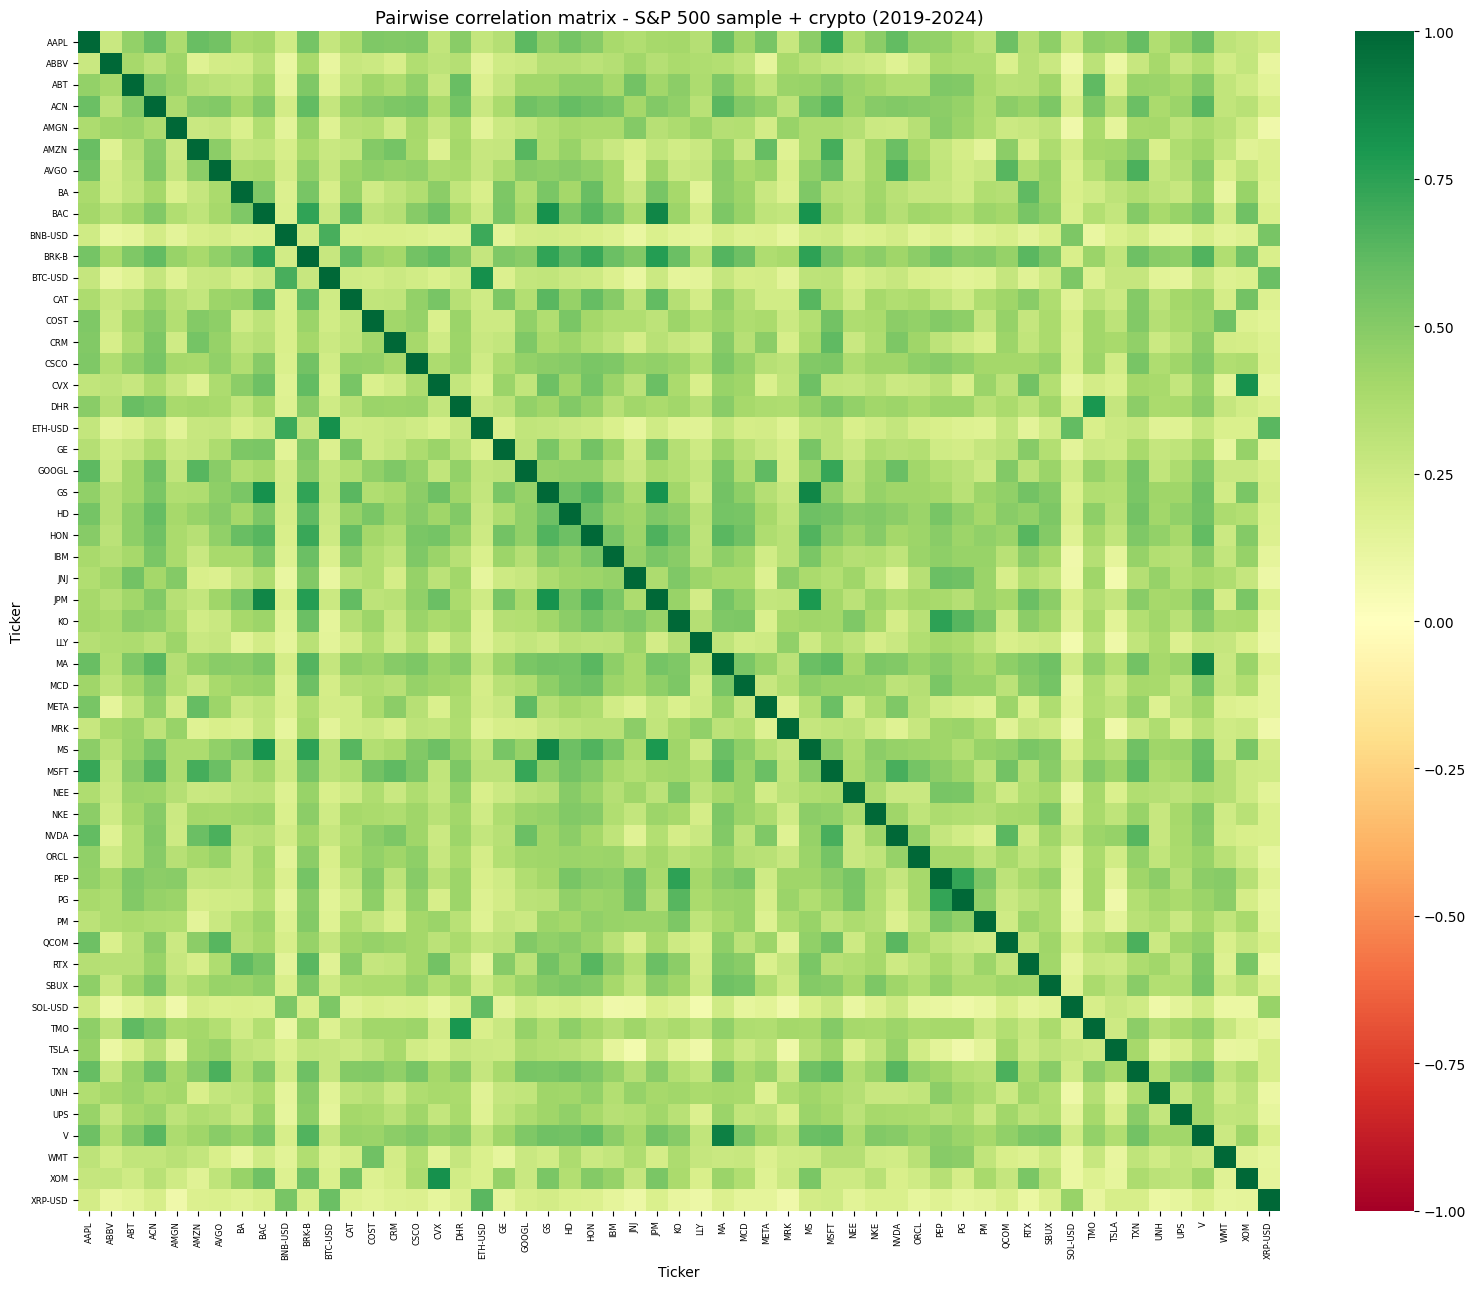

In [ ]:
#Heatmap to visualize the correlation
corr_matrix = returns.corr()

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    cmap="RdYlGn",
    center=0, #To make sure the Yellow actually correspond to zero correlation
    vmin=-1, vmax=1, #To make sure the maxi and min actually are -1 and 1 and not relative min/max in the data
    linewidths=0,
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns
)
plt.title("Pairwise correlation matrix - S&P 500 sample + crypto (2019-2024)", fontsize=13)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

Interpretation : 
Equity correlations cluster strongly by sector. Crypto assets show systematically low correlation with equities across the full 2019–2024 period, suggesting diversification potential — though this varies by asset and time period